# 01. EDA (탐색적 데이터 분석)
### 쇼핑 리뷰 데이터 기본 분석
---

## 0. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로딩 완료 ✅')

라이브러리 로딩 완료 ✅


---
## 1. 데이터 로딩

In [2]:
FILE_PATH = '../data/naver_shopping.txt'

df = pd.read_csv(
    FILE_PATH,
    sep='\t',
    header=None,
    names=['score', 'content'],
    encoding='utf-8'
)

print(f'데이터 로딩 완료 ✅')
print(f'총 데이터 수 : {len(df):,}개')
df.head(10)

데이터 로딩 완료 ✅
총 데이터 수 : 200,000개


,score,content
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
5,2,비추합니다 계란 뒤집을 때 완전 불편해요 ㅠㅠ 코팅도 묻어나고 보기엔 예쁘고 실용적...
6,1,주문을 11월6에 시켰는데 11월16일에 배송이 왔네요 ㅎㅎㅎ 여기 회사측과는 전화...
7,2,넉넉한 길이로 주문했는데도 안 맞네요 별로예요
8,2,보폴이 계속 때처럼 나오다가 지금은 안나네요~
9,2,110인데 전문속옷브랜드 위생팬티105보다 작은듯해요. 불편해요. 밴딩부분이 다 신...


---
## 2. 기본 정보 확인

In [3]:
print('=== 데이터 기본 정보 ===')
print(f'행 x 열 : {df.shape}')
print()
df.info()

=== 데이터 기본 정보 ===
행 x 열 : (200000, 2)

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   score    200000 non-null  int64
 1   content  200000 non-null  str  
dtypes: int64(1), str(1)
memory usage: 3.1 MB


In [4]:
print('=== 결측치 확인 ===')
print(df.isnull().sum())
print()

# 결측치 제거
before = len(df)
df = df.dropna()
df = df.reset_index(drop=True)
after = len(df)

print(f'결측치 제거 전 : {before:,}개')
print(f'결측치 제거 후 : {after:,}개')
print(f'제거된 행 수   : {before - after:,}개')

=== 결측치 확인 ===
score      0
content    0
dtype: int64

결측치 제거 전 : 200,000개
결측치 제거 후 : 200,000개
제거된 행 수   : 0개


In [5]:
print('=== content 빈 문자열 확인 ===')
empty_count = (df['content'].str.strip() == '').sum()
print(f'빈 리뷰 수 : {empty_count:,}개')

# 빈 문자열 제거
df = df[df['content'].str.strip() != '']
df = df.reset_index(drop=True)
print(f'정제 후 총 데이터 수 : {len(df):,}개')

=== content 빈 문자열 확인 ===
빈 리뷰 수 : 0개
정제 후 총 데이터 수 : 200,000개


In [6]:
print('=== score 컬럼 타입 변환 ===')
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df = df.dropna(subset=['score'])
df['score'] = df['score'].astype(int)
print(df['score'].value_counts().sort_index())

=== score 컬럼 타입 변환 ===
score
1    36048
2    63989
4    18786
5    81177
Name: count, dtype: int64


---
## 3. 별점 분포 시각화

In [7]:
score_counts = df['score'].value_counts().sort_index()
score_ratio  = df['score'].value_counts(normalize=True).sort_index() * 100

print('=== 별점 분포 ===')
for score in score_counts.index:
    bar = '█' * int(score_ratio[score] / 2)
    print(f'{score}점 | {bar} {score_counts[score]:,}개 ({score_ratio[score]:.1f}%)')

=== 별점 분포 ===
1점 | █████████ 36,048개 (18.0%)
2점 | ███████████████ 63,989개 (32.0%)
4점 | ████ 18,786개 (9.4%)
5점 | ████████████████████ 81,177개 (40.6%)


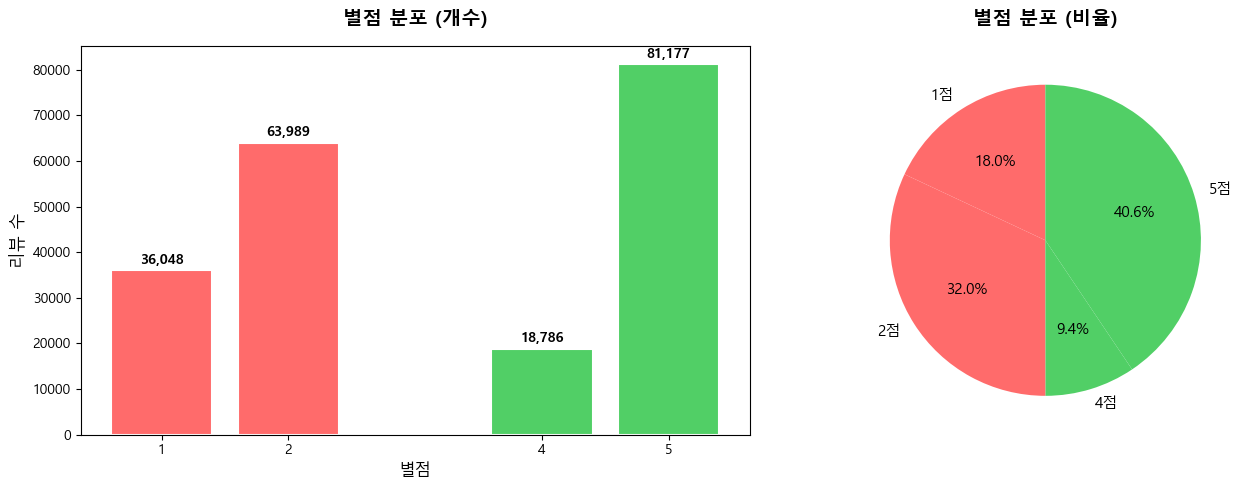

저장 완료 ✅


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽 - 막대 그래프
colors = ['#FF6B6B' if s <= 2 else '#51CF66' for s in score_counts.index]
bars = axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('별점 분포 (개수)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('별점', fontsize=12)
axes[0].set_ylabel('리뷰 수', fontsize=12)
axes[0].set_xticks(score_counts.index)
for bar, count in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(score_counts)*0.01,
                 f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 오른쪽 - 파이 차트
pie_colors = ['#FF6B6B' if s <= 2 else '#51CF66' for s in score_counts.index]
axes[1].pie(score_counts.values, labels=[f'{s}점' for s in score_counts.index],
            autopct='%1.1f%%', colors=pie_colors, startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('별점 분포 (비율)', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../output/01_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 4. 긍정 / 부정 라벨 변환
 4~5점 → 1 (긍정)

 1~2점 → 0 (부정)

In [9]:
# 긍/부정 라벨 생성
df['label'] = df['score'].apply(lambda x: 1 if x >= 4 else 0)

label_counts = df['label'].value_counts()
print('=== 긍/부정 분포 ===')
print(f'긍정 (1) : {label_counts[1]:,}개 ({label_counts[1]/len(df)*100:.1f}%)')
print(f'부정 (0) : {label_counts[0]:,}개 ({label_counts[0]/len(df)*100:.1f}%)')

=== 긍/부정 분포 ===
긍정 (1) : 99,963개 (50.0%)
부정 (0) : 100,037개 (50.0%)


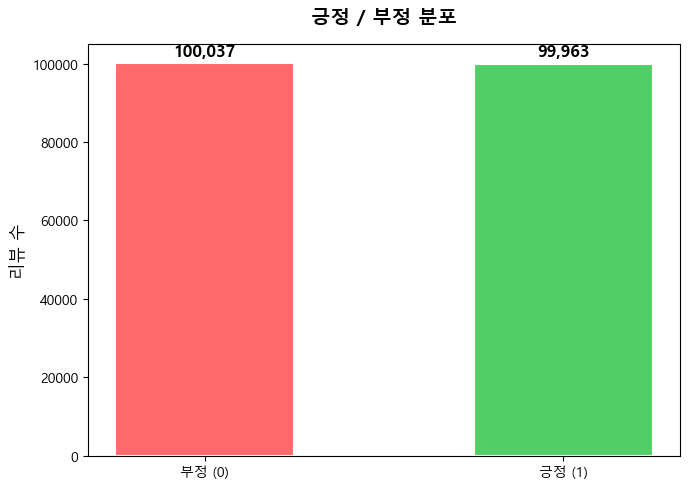

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(['부정 (0)', '긍정 (1)'], 
              [label_counts[0], label_counts[1]],
              color=['#FF6B6B', '#51CF66'], edgecolor='white', linewidth=1.5, width=0.5)

ax.set_title('긍정 / 부정 분포', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('리뷰 수', fontsize=12)

for bar, count in zip(bars, [label_counts[0], label_counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(label_counts)*0.01,
            f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/02_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. 리뷰 길이 분포

In [11]:
# 리뷰 길이 컬럼 추가
df['content_len'] = df['content'].str.len()

print('=== 리뷰 길이 통계 ===')
print(df['content_len'].describe().apply(lambda x: f'{x:.1f}'))
print()
print(f'가장 짧은 리뷰 : {df["content_len"].min()}자')
print(f'가장 긴 리뷰   : {df["content_len"].max()}자')
print(f'평균 리뷰 길이 : {df["content_len"].mean():.1f}자')

=== 리뷰 길이 통계 ===
count    200000.0
mean         39.7
std          29.2
min           3.0
25%          17.0
50%          29.0
75%          55.0
max         140.0
Name: content_len, dtype: str

가장 짧은 리뷰 : 3자
가장 긴 리뷰   : 140자
평균 리뷰 길이 : 39.7자


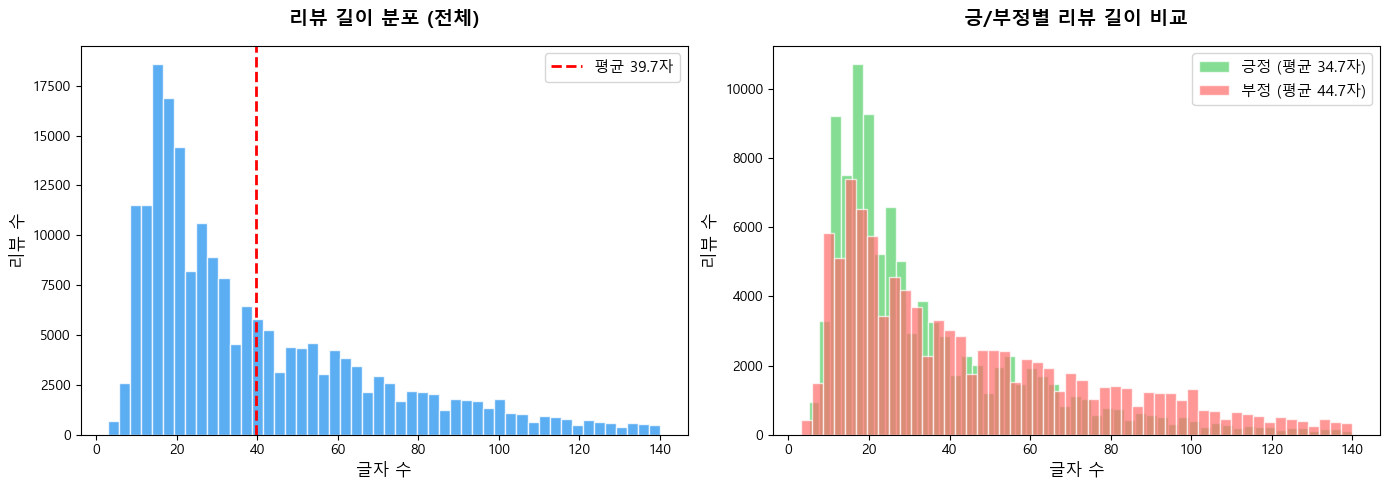

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 리뷰 길이 분포
axes[0].hist(df['content_len'], bins=50, color='#339AF0', edgecolor='white', alpha=0.8)
axes[0].axvline(df['content_len'].mean(), color='red', linestyle='--', linewidth=2, label=f'평균 {df["content_len"].mean():.1f}자')
axes[0].set_title('리뷰 길이 분포 (전체)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('글자 수', fontsize=12)
axes[0].set_ylabel('리뷰 수', fontsize=12)
axes[0].legend(fontsize=11)

# 긍/부정별 리뷰 길이 비교
pos_len = df[df['label'] == 1]['content_len']
neg_len = df[df['label'] == 0]['content_len']
axes[1].hist(pos_len, bins=50, color='#51CF66', edgecolor='white', alpha=0.7, label=f'긍정 (평균 {pos_len.mean():.1f}자)')
axes[1].hist(neg_len, bins=50, color='#FF6B6B', edgecolor='white', alpha=0.7, label=f'부정 (평균 {neg_len.mean():.1f}자)')
axes[1].set_title('긍/부정별 리뷰 길이 비교', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('글자 수', fontsize=12)
axes[1].set_ylabel('리뷰 수', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('../output/03_content_length.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. 자주 나오는 단어 확인

In [13]:
# 간단한 공백 기준 토크나이징 (형태소 분석기 없이)
# 특수문자 제거 후 단어 추출
def get_words(texts):
    words = []
    for text in texts:
        text = re.sub(r'[^가-힣a-zA-Z\s]', ' ', str(text))
        words.extend(text.split())
    # 2글자 이상 단어만
    words = [w for w in words if len(w) >= 2]
    return words

# 전체 단어 빈도
all_words   = get_words(df['content'])
pos_words   = get_words(df[df['label'] == 1]['content'])
neg_words   = get_words(df[df['label'] == 0]['content'])

all_counter = Counter(all_words)
pos_counter = Counter(pos_words)
neg_counter = Counter(neg_words)

print('=== 전체 상위 20개 단어 ===')
for word, count in all_counter.most_common(20):
    print(f'  {word} : {count:,}회')

=== 전체 상위 20개 단어 ===
  너무 : 22,393회
  좋아요 : 17,830회
  재구매 : 13,893회
  그냥 : 10,069회
  많이 : 6,720회
  생각보다 : 6,274회
  같아요 : 5,911회
  배송도 : 5,479회
  좋네요 : 5,286회
  배송 : 5,077회
  정말 : 4,779회
  좋습니다 : 4,271회
  만족합니다 : 4,090회
  빠르고 : 4,004회
  진짜 : 3,831회
  샀는데 : 3,821회
  배송이 : 3,747회
  아주 : 3,689회
  감사합니다 : 3,435회
  조금 : 3,144회


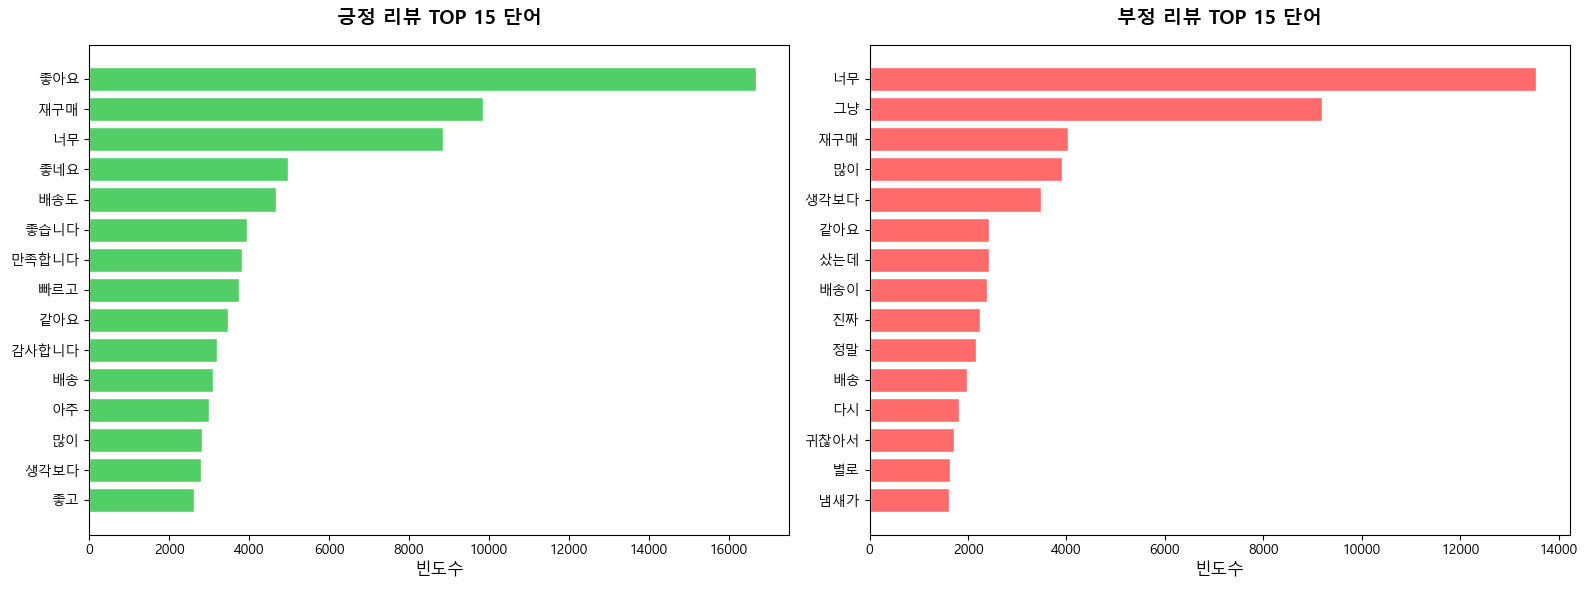

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 긍정 상위 15개
pos_top15 = pos_counter.most_common(15)
pos_words_list  = [w for w, _ in pos_top15]
pos_counts_list = [c for _, c in pos_top15]
axes[0].barh(pos_words_list[::-1], pos_counts_list[::-1], color='#51CF66', edgecolor='white')
axes[0].set_title('긍정 리뷰 TOP 15 단어', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('빈도수', fontsize=12)

# 부정 상위 15개
neg_top15 = neg_counter.most_common(15)
neg_words_list  = [w for w, _ in neg_top15]
neg_counts_list = [c for _, c in neg_top15]
axes[1].barh(neg_words_list[::-1], neg_counts_list[::-1], color='#FF6B6B', edgecolor='white')
axes[1].set_title('부정 리뷰 TOP 15 단어', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('빈도수', fontsize=12)

plt.tight_layout()
plt.savefig('../output/04_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. 별점별 평균 리뷰 길이

=== 별점별 평균 리뷰 길이 ===
score
1    46.9
2    43.4
4    37.6
5    34.0
Name: content_len, dtype: float64


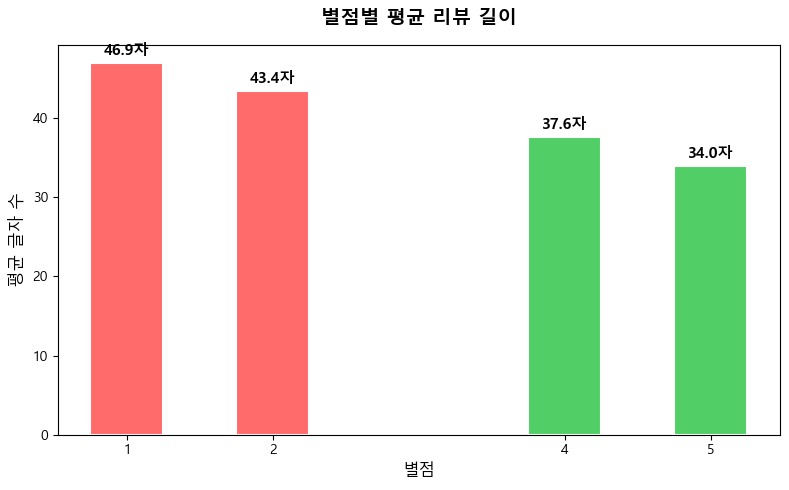

In [15]:
avg_len_by_score = df.groupby('score')['content_len'].mean().round(1)
print('=== 별점별 평균 리뷰 길이 ===')
print(avg_len_by_score)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#FF6B6B' if s <= 2 else '#51CF66' for s in avg_len_by_score.index]
bars = ax.bar(avg_len_by_score.index, avg_len_by_score.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('별점별 평균 리뷰 길이', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('별점', fontsize=12)
ax.set_ylabel('평균 글자 수', fontsize=12)
ax.set_xticks(avg_len_by_score.index)
for bar, val in zip(bars, avg_len_by_score.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}자', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/05_avg_len_by_score.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. 정제된 데이터 저장
> 다음 단계(02_preprocessing)에서 사용할 파일로 저장

In [16]:
df.to_csv('../data/reviews_eda.csv', index=False, encoding='utf-8-sig')
print('저장 완료 ✅')
print(f'저장 경로 : ../data/reviews_eda.csv')
print(f'최종 데이터 크기 : {df.shape}')
print()
print('=== 최종 데이터 샘플 ===')
df.head()

저장 완료 ✅
저장 경로 : ../data/reviews_eda.csv
최종 데이터 크기 : (200000, 4)

=== 최종 데이터 샘플 ===


,score,content,label,content_len
0,5,배공빠르고 굿,1,7
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,29
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,1,68
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,0,136
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1,33


---
## ✅ EDA 완료 요약

| 항목 | 내용                                 |
|---|------------------------------------|
| 총 데이터 수 | 확인 필요                              |
| 컬럼 | score, content, label, content_len |
| label 구성 | 0=부정(1~2점), 1=긍정(4\~5점)            |
| 다음 단계 | 02_preprocessing.ipynb             |

---